In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
df = pd.read_csv("websiteData.csv",header=1).copy()

In [50]:
df.head(2)

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526667,0.607595,4.673333,0.480000,1402
1,Organic Social,2024041719,208,267,132,32.097378,0.634615,4.295880,0.494382,1147


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Session primary channel group (Default channel group)  3182 non-null   object 
 1   Date + hour (YYYYMMDDHH)                               3182 non-null   int64  
 2   Users                                                  3182 non-null   int64  
 3   Sessions                                               3182 non-null   int64  
 4   Engaged sessions                                       3182 non-null   int64  
 5   Average engagement time per session                    3182 non-null   float64
 6   Engaged sessions per user                              3182 non-null   float64
 7   Events per session                                     3182 non-null   float64
 8   Engagement rate                                 

In [90]:
#converting the col date + hour into date format
df["Date + hour (YYYYMMDDHH)"] = pd.to_datetime(df["Date + hour (YYYYMMDDHH)"],format="%Y%m%d%H",errors='coerce')

In [52]:
#saperating date and hour in two cols
df["Date + hour (YYYYMMDDHH)"] = df["Date + hour (YYYYMMDDHH)"].astype('str')

In [53]:
date = df["Date + hour (YYYYMMDDHH)"].str.split(' ').str.get(0)

In [54]:
df.insert(1,'Date',date)

In [55]:
time = df["Date + hour (YYYYMMDDHH)"].str.split(' ').str.get(1)

In [56]:
df.insert(2,'Time',time)

In [57]:
df.drop(columns={'Date + hour (YYYYMMDDHH)'},inplace=True)

In [66]:
df['Date'] = pd.to_datetime(df['Date'])

In [77]:
df['Time'] = pd.to_datetime(df['Time'])

C:\Users\hp\AppData\Local\Temp\ipykernel_6612\2145562215.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


In [84]:
df['Time'] = df['Time'].dt.time

In [100]:
df.rename(columns={'Session primary channel group (Default channel group)':'Channel group'},inplace=True)

In [101]:
df['Channel group'].value_counts()

Channel group
Direct            672
Organic Social    672
Organic Search    672
Referral          672
Unassigned        366
Organic Video     125
Email               3
Name: count, dtype: int64

In [96]:
hour = df['Date + hour (YYYYMMDDHH)'].dt.hour

In [98]:
df.insert(2,'Hour',hour)

In [103]:
df.rename(columns={'Date + hour (YYYYMMDDHH)':'Date'},inplace=True)

In [108]:
df['Date'] = df['Date'].astype('str').str.split(" ").str.get(0)

In [110]:
df['Date'] = pd.to_datetime(df['Date'])

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel group                        3182 non-null   object        
 1   Date                                 3182 non-null   datetime64[ns]
 2   Hour                                 3182 non-null   int32         
 3   Users                                3182 non-null   int64         
 4   Sessions                             3182 non-null   int64         
 5   Engaged sessions                     3182 non-null   int64         
 6   Average engagement time per session  3182 non-null   float64       
 7   Engaged sessions per user            3182 non-null   float64       
 8   Events per session                   3182 non-null   float64       
 9   Engagement rate                      3182 non-null   float64       
 10  Event count 

In [112]:
df.describe()

,Date,Hour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-19 13:28:41.935889152,11.807040,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470
min,2024-04-06 00:00:00,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,2024-04-13 00:00:00,6.000000,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000
50%,2024-04-20 00:00:00,12.000000,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000
75%,2024-04-26 00:00:00,18.000000,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000
max,2024-05-03 00:00:00,23.000000,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000
std,NaN,6.886686,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313


# Problem Statements

### 1. What patterns or trends can you observe in website sessions users over time?

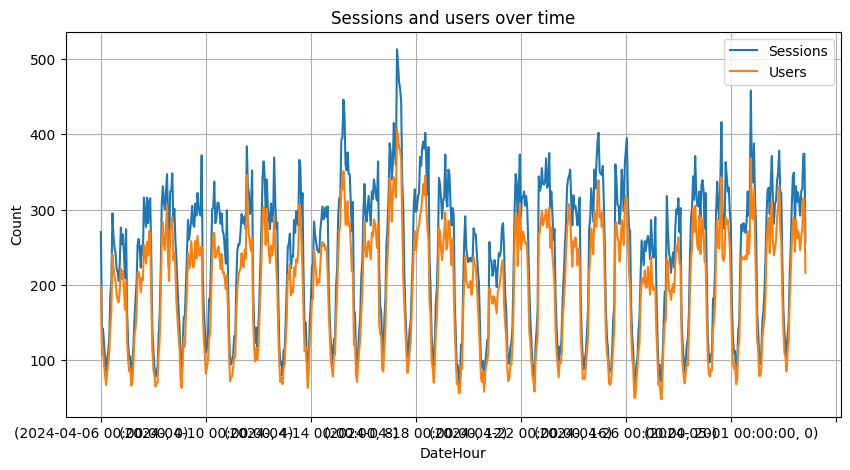

In [124]:
plt.figure(figsize=(10,5))

df.groupby(['Date','Hour'])[['Sessions','Users']].sum().plot(ax=plt.gca())
plt.xlabel('DateHour')
plt.ylabel('Count')
plt.title('Sessions and users over time')
plt.grid()
plt.show()

### 2. Which marketing channel brought the highest number of users to the website,and how can we use this insight to improve traffic from other sources?

In [139]:
df1 = df.groupby('Channel group')['Users'].sum().reset_index().sort_values(by='Users',ascending=False)

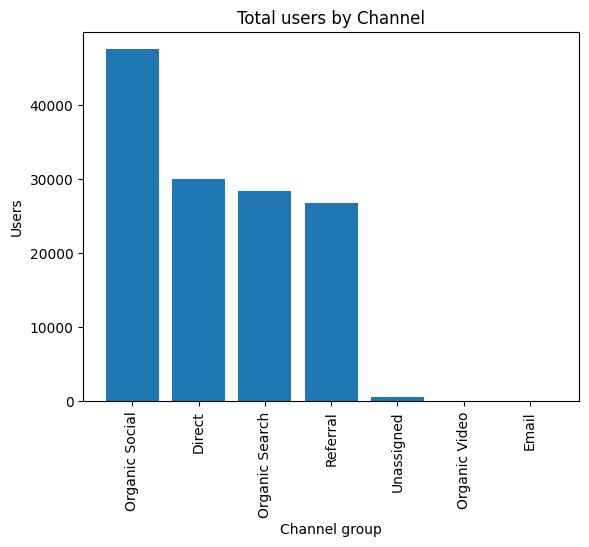

In [154]:
plt.bar(df1['Channel group'],df1['Users'])
plt.title('Total users by Channel')
plt.xlabel('Channel group')
plt.ylabel('Users')
plt.xticks(rotation='vertical')
plt.show()

### 3. Which channel has the highest average engagement time, and what does that tell us about user behaviour and content effectiveness

In [161]:
df1 = df.groupby('Channel group')['Average engagement time per session'].mean().reset_index().sort_values(by='Average engagement time per session',ascending=False)

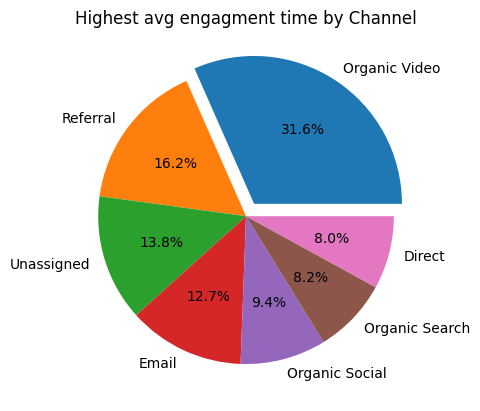

In [175]:
plt.pie(df1['Average engagement time per session'],labels=df1['Channel group'],autopct="%0.1f%%",explode=[0.1,0,0,0,0,0,0])
plt.title('Highest avg engagment time by Channel')
plt.show()

### 4. How does engagement rate vary across different traffic channels?

In [185]:
df1 = df.groupby('Channel group')['Engagement rate'].sum().reset_index()

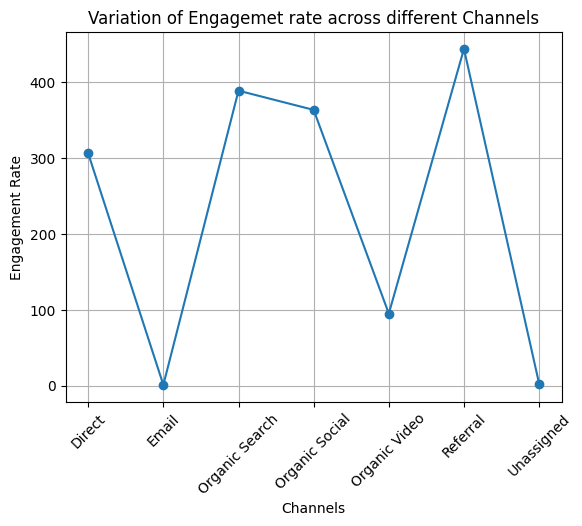

In [204]:
plt.plot(df1['Channel group'],df1['Engagement rate'],linestyle='solid',marker="o")
plt.title('Variation of Engagemet rate across different Channels')
plt.xticks(rotation = 45)
plt.xlabel('Channels')
plt.ylabel('Engagement Rate')
plt.grid()
plt.show()

### 5. Which channels are driving more engaged sessions comapared to non-engaged ones,and what strategies can improve engagement in underperforming channels?

In [206]:
#creating non-engaged sessions column
df['Non-Engaged'] = df['Sessions'] - df['Engaged sessions']

In [222]:
df1 = df.groupby('Channel group')[['Engaged sessions','Non-Engaged']].sum().reset_index()
df1Melted = df1.melt(id_vars='Channel group',value_vars=['Engaged sessions','Non-Engaged'])

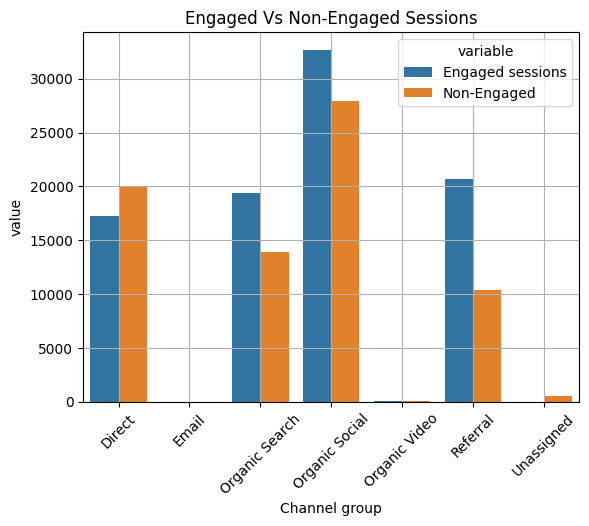

In [233]:
sns.barplot(data=df1Melted,x='Channel group',y='value',hue='variable')
plt.xticks(rotation=45)
plt.title('Engaged Vs Non-Engaged Sessions')
plt.grid()
plt.show()

### 6. At what hours of the day does each channel drive the most traffic?

In [239]:
heatMapData = df.groupby(['Hour','Channel group'])['Sessions'].sum().unstack().fillna(0)

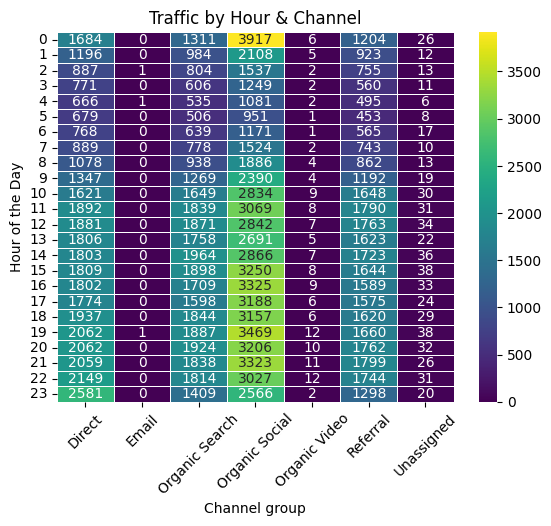

In [251]:
sns.heatmap(heatMapData,cmap='viridis',linewidth=.5,annot=True,fmt='.0f')
plt.title('Traffic by Hour & Channel')
plt.xlabel('Channel group')
plt.ylabel('Hour of the Day')
plt.xticks(rotation=45)
plt.show()

### 7. Is there any correlation between high traffic(sessions) and high engagement rate over time?

In [261]:
df1 = df.groupby('Date')[['Engagement rate','Sessions']].mean().reset_index()

In [262]:
df1.head()

,Date,Engagement rate,Sessions
0,2024-04-06,0.497897,42.526786
1,2024-04-07,0.522002,47.962963
2,2024-04-08,0.520934,52.305556
3,2024-04-09,0.511275,48.877193
4,2024-04-10,0.518014,50.568966


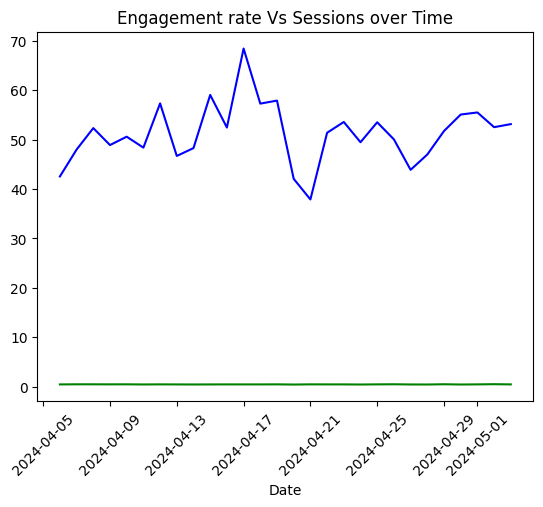

In [272]:
plt.plot(df1['Date'],df1['Engagement rate'],label='Engagement rate',color='green')
plt.plot(df1['Date'],df1['Sessions'],label='Sessions',color='blue')
plt.title('Engagement rate Vs Sessions over Time')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.show()

In [273]:
df

,Channel group,Date,Hour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Non-Engaged
0,Direct,2024-04-16,23,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,156
1,Organic Social,2024-04-17,19,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,135
2,Direct,2024-04-17,23,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,118
3,Organic Social,2024-04-17,18,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,131
4,Organic Social,2024-04-17,20,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,109
...,...,...,...,...,...,...,...,...,...,...,...,...
3177,Unassigned,2024-04-28,6,0,1,0,0.000000,0.000000,2.000000,0.000000,2,1
3178,Unassigned,2024-04-30,5,0,1,0,0.000000,0.000000,2.000000,0.000000,2,1
3179,Unassigned,2024-04-30,6,0,1,0,0.000000,0.000000,2.000000,0.000000,2,1
3180,Unassigned,2024-05-01,5,0,1,0,0.000000,0.000000,2.000000,0.000000,2,1
